In [1]:
import warnings
warnings.simplefilter('ignore')
import os
import glob
import numpy as np
from datetime import datetime
from matplotlib import pyplot as plt
import sunpy
from sunpy.map import Map
from astropy import units as u
from sunpy.time import parse_time
from astropy.coordinates import SkyCoord
from aiapy.calibrate.prep import correct_degradation
from aiapy.calibrate import register, update_pointing
from astropy.visualization import ImageNormalize, SqrtStretch
from tqdm import tqdm

data_dir = '/home/mnedal/data'

In [2]:
date = '2025-10-06'
channel = 304
year, month, day = date.split('-')
print(year, month, day)

2025 10 06


In [3]:
files = sorted(glob.glob(f'{data_dir}/AIA/{channel}A/highres/lv15/aia.lev15.{channel}A_{year}_{month}_{day}T*_lev15*.fits'))
print(len(files), *files, sep='\n')

600
/home/mnedal/data/AIA/304A/highres/lv15/aia.lev15.304A_2025_10_06T08_30_05.13Z.image_lev15.fits
/home/mnedal/data/AIA/304A/highres/lv15/aia.lev15.304A_2025_10_06T08_30_17.13Z.image_lev15.fits
/home/mnedal/data/AIA/304A/highres/lv15/aia.lev15.304A_2025_10_06T08_30_29.13Z.image_lev15.fits
/home/mnedal/data/AIA/304A/highres/lv15/aia.lev15.304A_2025_10_06T08_30_41.13Z.image_lev15.fits
/home/mnedal/data/AIA/304A/highres/lv15/aia.lev15.304A_2025_10_06T08_30_53.15Z.image_lev15.fits
/home/mnedal/data/AIA/304A/highres/lv15/aia.lev15.304A_2025_10_06T08_31_05.13Z.image_lev15.fits
/home/mnedal/data/AIA/304A/highres/lv15/aia.lev15.304A_2025_10_06T08_31_17.13Z.image_lev15.fits
/home/mnedal/data/AIA/304A/highres/lv15/aia.lev15.304A_2025_10_06T08_31_29.13Z.image_lev15.fits
/home/mnedal/data/AIA/304A/highres/lv15/aia.lev15.304A_2025_10_06T08_31_41.13Z.image_lev15.fits
/home/mnedal/data/AIA/304A/highres/lv15/aia.lev15.304A_2025_10_06T08_31_53.14Z.image_lev15.fits
/home/mnedal/data/AIA/304A/highres/l

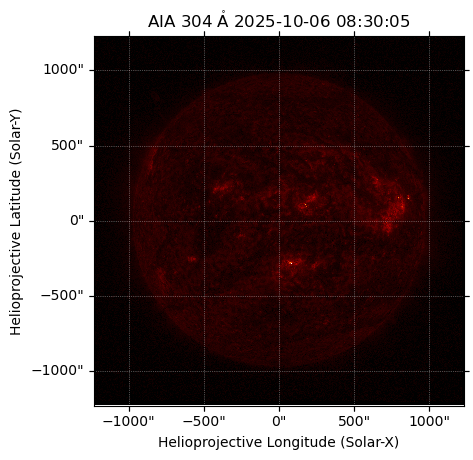

In [4]:
sequence = sunpy.map.Map(files, sequence=True)

fig = plt.figure()
ax = fig.add_subplot(projection=sequence.maps[0])
ani = sequence.plot(axes=ax, norm=ImageNormalize(vmin=0, vmax=5e3, stretch=SqrtStretch()))
plt.show()

In [106]:
for m in sequence:
    m.plot_settings['norm'] = ImageNormalize(vmin=-10, vmax=5e2, stretch=SqrtStretch())

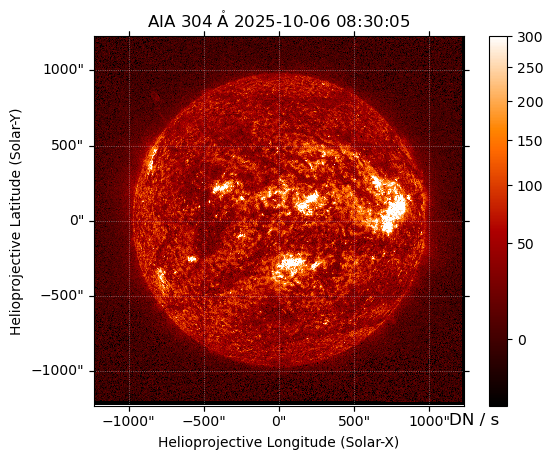

In [75]:
sequence.maps[0].peek()

In [108]:
target = parse_time('2025-10-06T10:00:00')

idx = np.argmin([abs(m.date - target) for m in sequence.maps])
print(idx)
aia = sequence[idx]

450


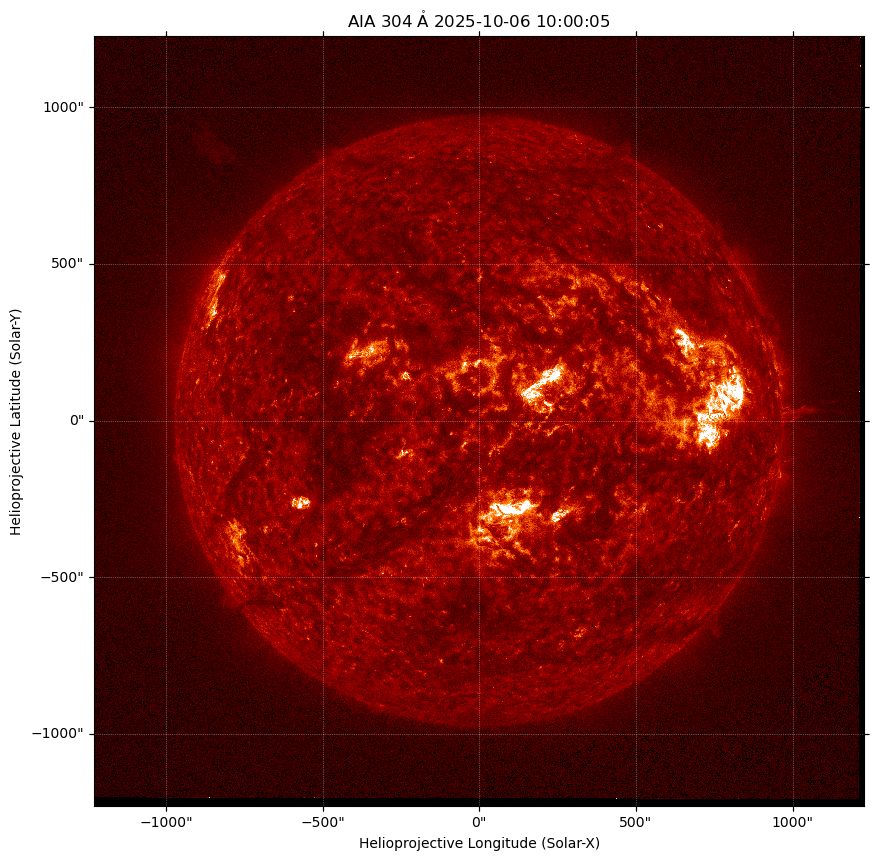

In [109]:
fig = plt.figure(figsize=[10,10])
ax  = fig.add_subplot(projection=aia)
aia.plot(axes=ax)
# ax.grid(False)
plt.show()

In [113]:
with tqdm(total=len(files), desc=f'Export AIA maps ...') as pbar:
    for m in sequence:
        fig = plt.figure(figsize=[7,7])
        ax  = fig.add_subplot(projection=m)
        m.plot(axes=ax)
        ax.grid(False)
        fig.savefig(f"{data_dir}/AIA/{channel}A/highres/lv15/submaps/aia_{channel}A_lv15_FullDisk_{m.meta['date-obs'][:-3]}.png", format='png', bbox_inches='tight')
        plt.close()
        pbar.update(1)

Export AIA maps ...: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [23:13<00:00,  2.32s/it]


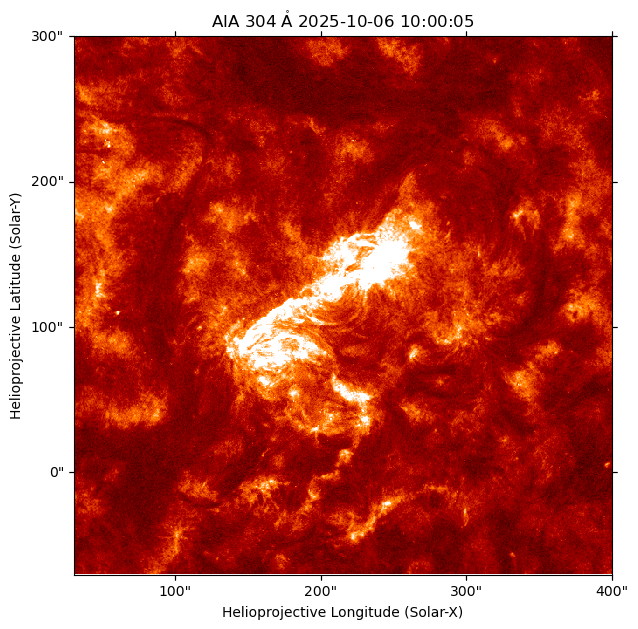

In [110]:
top_right   = SkyCoord(400*u.arcsec, 300*u.arcsec, frame=aia.coordinate_frame)
bottom_left = SkyCoord(30*u.arcsec, -70*u.arcsec, frame=aia.coordinate_frame)
aia_submap  = aia.submap(bottom_left, top_right=top_right)

fig = plt.figure(figsize=[7,7])
ax  = fig.add_subplot(projection=aia_submap)
aia_submap.plot(axes=ax)
ax.grid(False)
plt.show()

In [111]:
os.makedirs(f'{data_dir}/AIA/{channel}A/highres/lv15/submaps', exist_ok=True)

In [112]:
region = 1

with tqdm(total=len(files), desc=f'Export AIA submaps ...') as pbar:
    for m in sequence:
        if region==1:
            top_right   = SkyCoord(400*u.arcsec, 300*u.arcsec, frame=m.coordinate_frame)
            bottom_left = SkyCoord(30*u.arcsec, -70*u.arcsec, frame=m.coordinate_frame)
        elif region==2:
            top_right   = SkyCoord(1230*u.arcsec, 300*u.arcsec, frame=m.coordinate_frame)
            bottom_left = SkyCoord(800*u.arcsec, -350*u.arcsec, frame=m.coordinate_frame)
        else:
            break

        m_submap  = m.submap(bottom_left, top_right=top_right)
        
        fig = plt.figure(figsize=[7,7])
        ax  = fig.add_subplot(projection=m_submap)
        m_submap.plot(axes=ax)
        ax.grid(False)
        fig.savefig(f"{data_dir}/AIA/{channel}A/highres/lv15/submaps/aia_{channel}A_lv15_Reg{region}_{m.meta['date-obs'][:-3]}.png", format='png', bbox_inches='tight')
        plt.close()
        pbar.update(1)

Export AIA submaps ...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [06:15<00:00,  1.60it/s]
